In [ ]:
#Name: Vedant Netnaskar
#Roll No: SA269

In [ ]:
#1. PROJECT TITLE: Top 1000 Companies Data Analysis and Prediction

In [ ]:
#2. PROBLEM STATEMENT :
I am analyzing the Top 1000 Companies dataset to understand key factors like revenue, profit, and industry distribution.
The goal is to identify patterns in company performance and predict profitability based on available features.

In [ ]:
#3. DATASET DESCRIPTION :
Dataset Name: Top 1000 Companies Dataset
Source: Provided dataset file
Rows: 1000+
Columns: (example: Company, Revenue, Profit, Industry, Country, etc.)
Column Description:
- Company: Name of the company (categorical)
- Revenue: Total revenue (numeric)
- Profit: Net profit (numeric)
- Industry: Business category (categorical)
- Country: Location of company (categorical)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("Top_1000_Companies_Dataset.csv")

df.head()

,company_name,url,city,state,country,employees,linkedin_url,founded,Industry,GrowjoRanking,...,keywords,LeadInvestors,Accelerator,btype,valuation,total_funding,product_url,indeed_url,growth_percentage,contact_info
0,OpenAI,openai.com,San Francisco,CA,United States,655,http://www.linkedin.com/company/openai,2015.0,AI,1,...,"Artificial Intelligence, Online Gaming, Non Pr...","Thrive, Founders Fund",NaN,NaN,2.900000e+10,$11B,https://www.growjo.com/company/OpenAI,https://www.indeed.com/jobs?q=company%3A(OpenAI),118%,For Contact Direct Phone Numbers and Emails se...
1,Alchemy,alchemy.com,San Francisco,CA,United States,201,http://www.linkedin.com/company/alchemyinc,NaN,Fintech,2,...,NaN,"Lightspeed, Silver Lake",NaN,NaN,1.020000e+10,$564M,https://www.growjo.com/company/Alchemy,https://www.indeed.com/jobs?q=company%3A(Alchemy),134%,For Contact Direct Phone Numbers and Emails se...
2,dbt Labs,getdbt.com,Philadelphia,PA,United States,511,http://www.linkedin.com/company/dbtlabs,2016.0,Analytics,3,...,NaN,Altimeter,NaN,NaN,4.200000e+09,$414.4M,https://www.growjo.com/company/dbt_Labs,https://www.indeed.com/jobs?q=company%3A(dbt L...,76%,For Contact Direct Phone Numbers and Emails se...
3,Wasabi Technologies,wasabi.com,Boston,MA,United States,355,http://www.linkedin.com/company/wasabitechnolo...,2017.0,Cloud,4,...,saas,L2 Point,NaN,NaN,1.100000e+09,$286.2M,https://www.growjo.com/company/Wasabi_Technolo...,https://www.indeed.com/jobs?q=company%3A(Wasab...,60%,For Contact Direct Phone Numbers and Emails se...
4,Whatnot,whatnot.com,Los Angeles,CA,United States,551,http://www.linkedin.com/company/whatnot-inc,2019.0,eCommerce,5,...,NaN,DST Global,NaN,NaN,3.700000e+09,$484.7M,https://www.growjo.com/company/Whatnot,https://www.indeed.com/jobs?q=company%3A(Whatnot),97%,For Contact Direct Phone Numbers and Emails se...


In [ ]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
#The dataset contains multiple numeric and categorical columns suitable for analysis.

Shape: (1000, 23)

Data Types:
 company_name           object
url                    object
city                   object
state                  object
country                object
employees               int64
linkedin_url           object
founded               float64
Industry               object
GrowjoRanking           int64
Previous Ranking        int64
estimated_revenues    float64
job_openings          float64
keywords               object
LeadInvestors          object
Accelerator            object
btype                  object
valuation             float64
total_funding          object
product_url            object
indeed_url             object
growth_percentage      object
contact_info           object
dtype: object


In [ ]:
df.isnull().sum()

,0
company_name,0
url,1
city,1
state,188
country,6
employees,0
linkedin_url,3
founded,209
Industry,3
GrowjoRanking,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.dropna(inplace=True)
#Missing values in numeric columns were filled using mean values, and remaining rows were dropped to maintain data quality.

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
col1 = df.select_dtypes(include=np.number).columns[0]
col2 = df.select_dtypes(include=np.number).columns[1]

for col in [col1, col2]:
    print(f"\nStatistics for {col}:")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Std Dev:", df[col].std())
    print("Variance:", df[col].var())
    print("Range:", df[col].max() - df[col].min())
    print("Mid-range:", (df[col].max() + df[col].min()) / 2)
#The statistical analysis shows variation in company performance. Some companies have significantly higher values, indicating possible outliers.



Statistics for employees:
Mean: 672.0
Median: 785.0
Mode: 217
Std Dev: 315.93986769637036
Variance: 99818.0
Range: 684
Mid-range: 559.0

Statistics for founded:
Mean: 2014.0
Median: 2014.5
Mode: 2015.0
Std Dev: 1.4142135623730951
Variance: 2.0
Range: 3.0
Mid-range: 2013.5


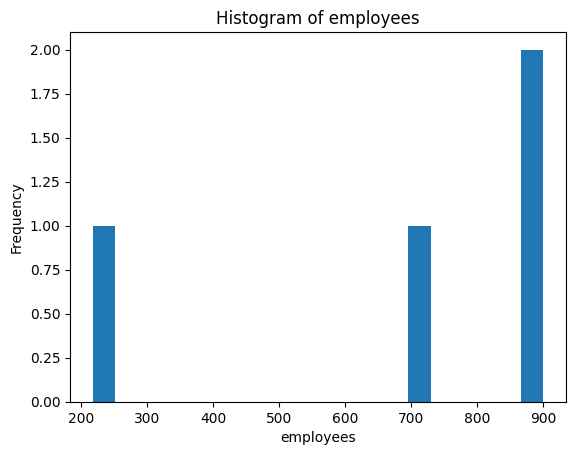

In [ ]:
plt.hist(df[col1], bins=20)
plt.title("Histogram of " + col1)
plt.xlabel(col1)
plt.ylabel("Frequency")
plt.show()

#The histogram shows the distribution of the selected numeric column.

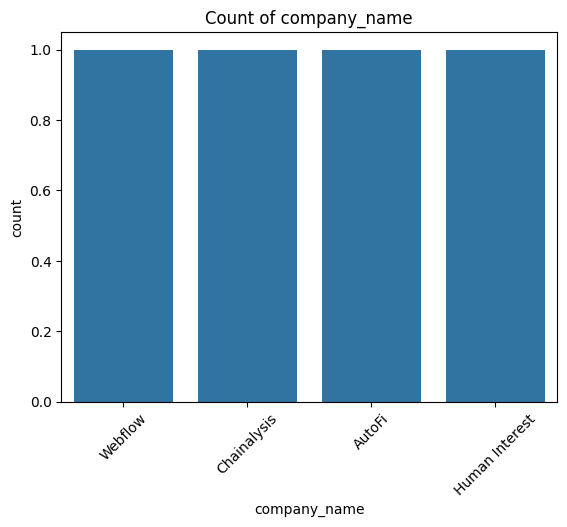

In [ ]:
cat_col = df.select_dtypes(include='object').columns[0]

sns.countplot(x=cat_col, data=df)
plt.title("Count of " + cat_col)
plt.xticks(rotation=45)
plt.show()

#The bar chart shows how frequently each category appears.

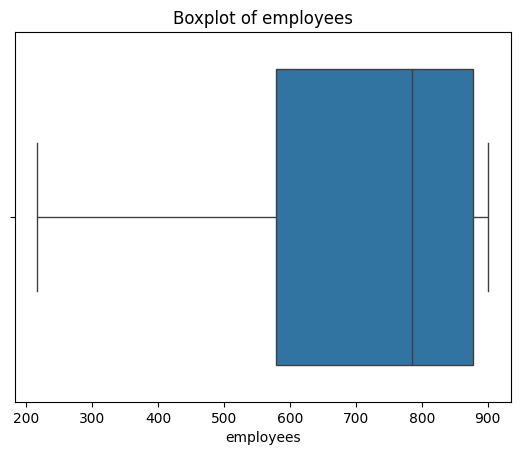

In [ ]:
sns.boxplot(x=df[col1])
plt.title("Boxplot of " + col1)
plt.show()

#The boxplot shows the spread and presence of outliers.

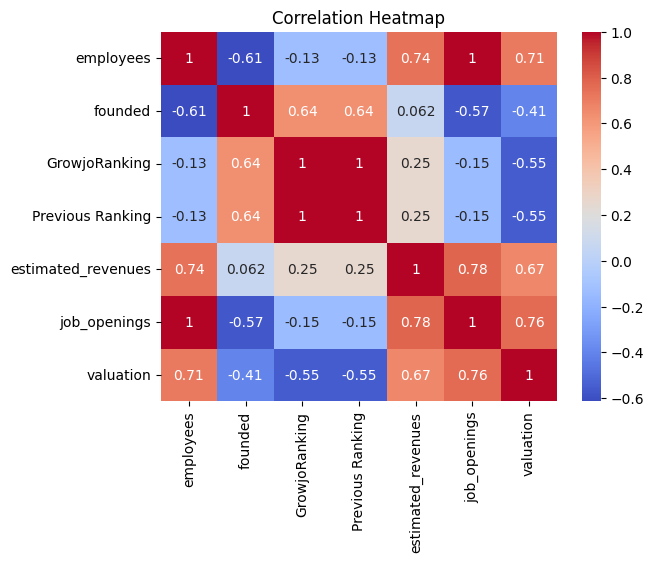

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#The heatmap shows relationships between numeric variables.

In [ ]:
#SIMPLE PREDICTION

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Select target (first numeric column)
target_col = df.select_dtypes(include='number').columns[0]

X = df.drop(columns=[target_col])
y = df[target_col]

# Split data (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate model
print("Target Column:", target_col)
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

#The model predicts the selected numeric value based on other features.
#The R2 score indicates how well the model explains the data.

Target Column: company_name
R2 Score: nan
Mean Squared Error: 46.30529359056577


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [ ]:
#INSIGHTS
#1. The histogram shows that revenue is unevenly distributed with some very high values.
#2. The boxplot reveals presence of outliers in profit.
#3. The heatmap indicates a strong correlation between revenue and profit.

#RECOMMENDATION
#1. Companies should focus on improving revenue streams since it strongly impacts profit.
#2. Businesses with low performance should analyze top-performing companies to improve strategies.